In [1]:
import numpy as np
import matplotlib.pyplot as plt

def collision(x1, y1, x2, y2, i, N, dmin, boundary_type, boundary_params):
    if boundary_type == "circle":
        cx = boundary_params["cx"]
        cy = boundary_params["cy"]
        r  = boundary_params["r"]
        if np.sqrt((x1 - cx)**2 + (y1 - cy)**2) >= r:
            return 0

    c = [n for n in range(N) if n != i]
    for k in c:
        for j in range(len(x2[k])):
            if (x1 - x2[k][j])**2 + (y1 - y2[k][j])**2 < dmin * dmin:
                return 0
    return 1


def run_simulation(config):
    N = config["N"]
    L = config["L"]
    dr = config["dr"]
    a = config["a"]
    dmin = config["dmin"]
    time_step = config["time_step"]

    x0 = np.array([p[0] for p in config["points"]], dtype=float)
    y0 = np.array([p[1] for p in config["points"]], dtype=float)

    centerx = config["centerx"]
    centery = config["centery"]

    boundary_type = config["boundary_type"]
    boundary_params = config["boundary_params"]

    x = [[x0[i]] for i in range(N)]
    y = [[y0[i]] for i in range(N)]

    for t in range(1, time_step):
        theta = 2 * np.pi / (a * t)
        for i in range(N):
            for j in range(a * t):
                dx = centerx - x0[i]
                dy = centery - y0[i]
                value = np.arctan2(dy, dx)
                value += np.pi

                p = x[i][0] + t * dr * np.cos(j * theta + value)
                q = y[i][0] + t * dr * np.sin(j * theta + value)

                if collision(p, q, x, y, i, N, dmin, boundary_type, boundary_params) == 1:
                    x[i].append(p)
                    y[i].append(q)

    plt.figure(figsize=config.get("figsize", (6, 6)))
    for i in range(N):
        plt.scatter(x[i], y[i], s=config.get("marker_size", 20), c="white")

    plt.axis("off")
    plt.gcf().set_facecolor("black")
    # plt.savefig(config["save_name"], dpi=config.get("dpi", 300))
    plt.show()

    return x, y

In [6]:
configs = {
    "3_points": {
        "N": 3,
        "L": 12,
        "dr": 12/450,
        "a": 6,
        "dmin": 0.2,
        "time_step": 63,
        "points": [
            (6.1, 7.45),
            (4.5, 4.8),
            (7.7, 4.8),
        ],
        "centerx": 6,
        "centery": 5.4,
        "boundary_type": "circle",
        "boundary_params": {"cx": 6, "cy": 5.4, "r": 2.9},
        "figsize": (6, 6),
        "marker_size": 10,
        "save_name": "3points_sim4",
        "dpi": 300,
    },

    "4_points": {
        "N": 4,
        "L": 12,
        "dr": 12/400,
        "a": 6,
        "dmin": 0.20,
        "time_step": 60,
        "points": [
            (4.95, 7.0),
            (5.0, 5.0),
            (7.0, 4.85),
            (6.9, 6.9),
        ],
        "centerx": 6,
        "centery": 6,
        "boundary_type": "circle",
        "boundary_params": {"cx": 6, "cy": 6, "r": 6},
        "figsize": (7, 7),
        "marker_size": 35,
        "save_name": "4points_sim4",
        "dpi": 300,
    },

    "5_points_cross": {
        "N": 5,
        "L": 12,
        "dr": 12/300,
        "a": 6,
        "dmin": 0.2,
        "time_step": 50,
        "points": [
            (4.5, 7.4),
            (4.6, 4.7),
            (7.5, 4.5),
            (7.5, 7.4),
            (6.0, 6.0),
        ],
        "centerx": 6,
        "centery": 6,
        "boundary_type": "circle",
        "boundary_params": {"cx": 6, "cy": 6, "r": 6},
        "figsize": (7, 7),
        "marker_size": 25,
        "save_name": "sim",
        "dpi": 500,
    },

    "7_points_hex": {
        "N": 7,
        "L": 12,
        "dr": 12/300,
        "a": 6,
        "dmin": 0.25,
        "time_step": 50,
        "points": [
            (5.9, 8.0),
            (6.0 + 3**0.5, 7.15),
            (6.0 + 3**0.5, 5.0),
            (6.1, 4.0),
            (6.0 - 3**0.5, 4.85),
            (6.0 - 3**0.5, 7.1),
            (6.0, 6.0),
        ],
        "centerx": 6,
        "centery": 6,
        "boundary_type": "circle",
        "boundary_params": {"cx": 6, "cy": 6, "r": 6},
        "figsize": (7, 7),
        "marker_size": 25,
        "save_name": "sim",
        "dpi": 500,
    },

    "different_growth_rates": {
        "N": 2,
        "L": 10,
        "dr": [10/600, 10/1000],
        "a": 10,
        "dmin": 0.2,
        "time_step": 180,
        "points": [
            (3.7, 6.0),
            (5.5, 6.0),
        ],
        "centerx": None,
        "centery": None,
        "boundary_type": "circle",
        "boundary_params": {"cx": 4.2, "cy": 6, "r": 3.3},
        "figsize": (7, 7),
        "marker_size": 20,
        "save_name": None,
        "dpi": None,
        "xlim": (-1, 12),
        "ylim": (-1, 12),
        "growth_mode": "radial_no_center_bias",
    },

    "disorder1": {
        "N": 7,
        "L": 12,
        "dr": 12/300,
        "a": 6,
        "dmin": 0.4,
        "time_step": 83,
        "points": [
            (3.0, 6.2),
            (3.5, 3.8),
            (6.0, 6.5),
            (8.0, 3.0),
            (6.0, 5.9),
            (4.2, 7.6),
            (8.5, 9.0),
        ],
        "centerx": 6,
        "centery": 6,
        "boundary_type": "circle",
        "boundary_params": {"cx": 6, "cy": 6, "r": 6},
        "figsize": (7, 7),
        "marker_size": 55,
        "save_name": "dis1_sim15_t=80_d3_r300_fixedcenter",
        "dpi": 500,
        "xlim": (2, 10),
        "ylim": (2, 10),
    },

    "disorder2": {
        "N": 9,
        "L": 12,
        "dr": 12/300,
        "a": 6,
        "dmin": 0.5,
        "time_step": 70,
        "points": [
            (6.1, 5.8),
            (6.9, 6.9),
            (8.5, 8.7),
            (8.0, 9.0),
            (7.2, 4.1),
            (9.3, 4.4),
            (4.6, 4.0),
            (4.0, 5.9),
            (4.0, 7.4),
        ],
        "centerx": 6,
        "centery": 6,
        "boundary_type": "circle",
        "boundary_params": {"cx": 6, "cy": 6, "r": 6},
        "figsize": (7, 7),
        "marker_size": 55,
        "save_name": "dis2_sim42_t=70_d3_r300_fixedcenter",
        "dpi": 500,
        "xlim": (2, 10),
        "ylim": (2, 10),
    },

    "p1": {
        "N": 4,
        "L": 12,
        "dr": 12/350,
        "a": 6,
        "dmin": 0.3,
        "time_step": 45,
        "points": [
            (4.5, 4.5),
            (4.5, 7.5),
            (7.5, 4.5),
            (7.5, 7.5),
        ],
        "centerx": 6,
        "centery": 6,
        "boundary_type": "circle",
        "boundary_params": {"cx": 6, "cy": 6, "r": 6},
        "figsize": (6, 6),
        "marker_size": 20,
        "save_name": "p1_sim1",
        "dpi": 500,
    },

    "p2": {
        "N": 5,
        "L": 12,
        "dr": 12/350,
        "a": 6,
        "dmin": 0.3,
        "time_step": 35,
        "points": [
            (4.5, 4.5),
            (4.5, 7.5),
            (7.5, 4.5),
            (7.5, 7.5),
            (6.0, 6.0),
        ],
        "centerx": 6,
        "centery": 6,
        "boundary_type": "circle",
        "boundary_params": {"cx": 6, "cy": 6, "r": 6},
        "figsize": (6, 6),
        "marker_size": 20,
        "save_name": "p2_sim3",
        "dpi": 500,
    },

    "p3": {
        "N": 7,
        "L": 12,
        "dr": 12/350,
        "a": 6,
        "dmin": 0.3,
        "time_step": 40,
        "points": [
            (8.3094, 6.0),
            (7.1547, 8.0),
            (4.8453, 8.0),
            (3.6906, 6.0),
            (4.8453, 4.0),
            (7.1547, 4.0),
            (6.0, 6.0),
        ],
        "centerx": 6,
        "centery": 6,
        "boundary_type": "circle",
        "boundary_params": {"cx": 6, "cy": 6, "r": 6},
        "figsize": (6, 6),
        "marker_size": 20,
        "save_name": "p3_sim2",
        "dpi": 500,
    },
}


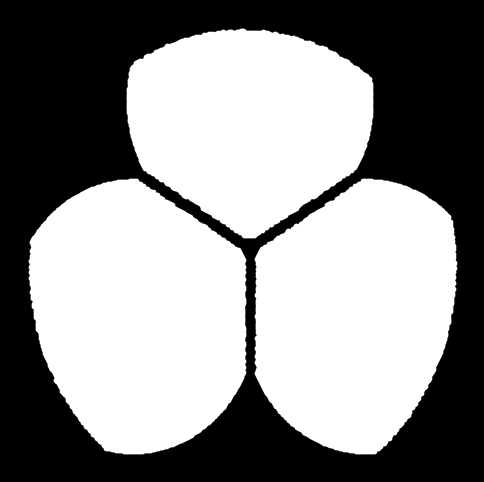

([[np.float64(6.1),
   np.float64(6.101299268099024),
   np.float64(6.077583050857837),
   np.float64(6.0762837827588125),
   np.float64(6.098700731900975),
   np.float64(6.1224169491421625),
   np.float64(6.123716217241187),
   np.float64(6.102598536198048),
   np.float64(6.075615402330166),
   np.float64(6.055166101715673),
   np.float64(6.046730007940005),
   np.float64(6.0525675655176245),
   np.float64(6.071114605609839),
   np.float64(6.097401463801951),
   np.float64(6.124384597669834),
   np.float64(6.144833898284326),
   np.float64(6.153269992059994),
   np.float64(6.147432434482375),
   np.float64(6.12888539439016),
   np.float64(6.103897804297072),
   np.float64(6.076333622456252),
   np.float64(6.0516239550257405),
   np.float64(6.03274915257351),
   np.float64(6.0219857948377165),
   np.float64(6.020632101611539),
   np.float64(6.028851348276437),
   np.float64(6.045652172381464),
   np.float64(6.069008146585798),
   np.float64(6.096102195702927),
   np.float64(6.123666377

In [7]:
run_simulation(configs["3_points"])